# 3: Predicting Regime Shifts Using XGBoost

The previous notebooks successfully calibrated a GARCH model under a Standardized Student's t-distribution, which was formally validated within the Basel Committee's Green Zone. However, traditional econometric models carry a critical limitation: they assume that volatility evolves continuously and smoothly over time. This assumption makes them short-sighted regarding sudden, structural regime shifts in financial markets.

To address this blind spot and provide the organization with a proactive risk management system, the objective of this notebook is to move beyond purely parametric modeling and implement an ensemble Machine Learning algorithm: XGBoost. Crucially, the model will not attempt to predict tomorrow's exact exchange rate. Instead, XGBoost will be trained to solve a Binary Classification problem focused on predicting extreme risk regimes:

* **Target Variable:** Using the previously established risk framework, days where VaR breaches occurred will be identified to construct a binary classification label:
* **Class 0 (Stability Regime):** Trading days where actual returns remained within the predicted VaR boundaries.
* **Class 1 (Panic Regime):** Trading days where actual returns breached the VaR threshold.

XGBoost will be trained to predict the conditional probability of the Mexican Peso shifting into Class 1 within the next 24 hours.

### Feature Engineering Matrix

Rather than feeding raw variables into the model, XGBoost will be supplied with the structured risk ecosystem analyzed in the previous notebooks, combining three distinct macroeconomic and statistical forces:

* **Mexican Peso Features:** The daily conditional volatility vector generated by the GARCH(1,1) model.
* **Global Macroeconomic Features:** Since the initial notebook utilized Granger Causality tests to prove that the VIX and U.S. Treasury yields (Tasa_Fed_10Y) causally precede the Mexican Peso with distinct temporal structures, lag features will be constructed. Specifically, lags 1 through 5 will be engineered for U.S. rates, and lags 1 through 2 for the VIX, strictly aligning with the previously validated informational leads.
* **Non-Linear Interaction Features:** A 21-day rolling Spearman rank correlation will be calculated to provide the algorithm with medium-term context on how the VIX and U.S. rates are coupling with the exchange rate channel prior to market stress events.

Following this framework, the required libraries and core datasets will be loaded and transformed into DataFrames to construct the feature engineering matrix that will feed the XGBoost model.


In [1]:
pip install xgboost scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve


In [3]:
df_var = pd.read_csv('matriz_volatilidad_var_garch.csv', index_col='Date', parse_dates=True)
df_main_log = pd.read_csv('data_main_log.csv', index_col='Date', parse_dates=True)
df_stable = pd.read_csv('data_stable.csv', index_col='Date', parse_dates=True)

In [4]:
# se inicia el DataFrame principal indexadopor df_var
X_master = pd.DataFrame(index=df_var.index)

# se agrega la Volatilidad GARCH desde df_var, pos construcción las volatilidades ya son libres de leakage
X_master['volatilidad_garch'] = df_var['volatilidad_garch']

# análogamente los rendimientos del peso rezagados 1 día para evitar leakage
X_master['rendimientos_usd_lag1'] = df_stable['USD_MXN_stable'].shift(1)

# se implementan los lags correspondientes a cada variable (VIX: 1 a 5, Tasa FED: 1 a 2)
for lag in range(1, 6):
    X_master[f'vix_lag_{lag}'] = df_stable['VIX_stable'].shift(lag)

for lag in range(1, 3):
    X_master[f'tasa_fed_lag_{lag}'] = df_stable['Tasa_Fed_10Y_stable'].shift(lag)


# correlación a 21 días financieros
X_master['correlacion_vix_usd_21d'] = X_master['vix_lag_1'].rolling(window=21).apply(lambda x: x.rank().corr(X_master['rendimientos_usd_lag1'].loc[x.index].rank()))
X_master['correlacion_tasa_usd_21d'] = X_master['tasa_fed_lag_1'].rolling(window=21).apply(lambda x: x.rank().corr(X_master['rendimientos_usd_lag1'].loc[x.index].rank()))

# eliminación de los NaN derivados de todos los rezagos y la ventana de 21 días
X_master = X_master.dropna()

print("DataFrame principal")
print(f"Dimensiones de la matriz (Filas, Columnas): {X_master.shape}")
print("\nVariables para alimentar al XGBoost:")
print(X_master.columns.tolist())


DataFrame principal
Dimensiones de la matriz (Filas, Columnas): (1367, 11)

Variables para alimentar al XGBoost:
['volatilidad_garch', 'rendimientos_usd_lag1', 'vix_lag_1', 'vix_lag_2', 'vix_lag_3', 'vix_lag_4', 'vix_lag_5', 'tasa_fed_lag_1', 'tasa_fed_lag_2', 'correlacion_vix_usd_21d', 'correlacion_tasa_usd_21d']


In [6]:
# confirmación del rango de fechas que sobrevivió al dropna
print(f"Desde: {X_master.index.min()} hasta: {X_master.index.max()}")
X_master.head()

Desde: 2021-02-04 00:00:00 hasta: 2026-07-16 00:00:00


,volatilidad_garch,rendimientos_usd_lag1,vix_lag_1,vix_lag_2,vix_lag_3,vix_lag_4,vix_lag_5,tasa_fed_lag_1,tasa_fed_lag_2,correlacion_vix_usd_21d,correlacion_tasa_usd_21d
Date,,,,,,,,,,,
2021-02-04,0.009266,-0.011380,22.910000,25.559999,30.240000,33.090000,30.209999,0.023257,0.025666,0.027273,0.145455
2021-02-05,0.008348,0.002945,21.770000,22.910000,25.559999,30.240000,33.090000,0.007049,0.023257,-0.046753,0.084416
2021-02-08,0.008595,0.009369,20.870001,21.770000,22.910000,25.559999,30.240000,0.026853,0.007049,-0.114286,0.148052
2021-02-09,0.009502,-0.013620,21.240000,20.870001,21.770000,22.910000,25.559999,-0.008584,0.026853,-0.033766,0.251948
2021-02-10,0.008406,-0.000414,21.629999,21.240000,20.870001,21.770000,22.910000,-0.002590,-0.008584,0.066234,0.172727


In [20]:
# el VaR que protege el hoy, se calculó con lo de ayer, por eso de hace el shift
var_superior_95_predictivo = df_var['VaR_Sup_95'].shift(1)

# condición de alerta
condicion_panico_real = df_var['USD_MXN_real_log'] > var_superior_95_predictivo

# fabricación del target en pura calma (0)
y_full = pd.Series(0, index=df_var.index)

# se rellena los que si marcaron la alerta
y_full[condicion_panico_real] = 1

# alineación con el índice de X_master
y = y_full.loc[X_master.index]

print(f"Dimensiones de la variable objetivo y: {y.shape}")
print("\nDistribución de regímenes en la base de datos (2021-2026):")
print(y.value_counts())

# proporción del desbalance de clases
proporcion_panico = (y.sum() / len(y)) * 100
print(f"\nPorcentaje de días de alerta (Clase 1): {proporcion_panico:.2f}%")

Dimensiones de la variable objetivo y: (1367,)

Distribución de regímenes en la base de datos (2021-2026):
0    1314
1      53
Name: count, dtype: int64

Porcentaje de días de alerta (Clase 1): 3.88%


In [21]:
# se fija el índice de corte al 80%
porcentaje_corte = 0.80
punto_corte = int(len(X_master) * porcentaje_corte)

# partición cronológica
X_train = X_master.iloc[:punto_corte]
X_test = X_master.iloc[punto_corte:]
y_train = y.iloc[:punto_corte]
y_test = y.iloc[punto_corte:]

# verificación del traslape de fechas
assert X_train.index.max() < X_test.index.min(), "¡Hay traslape de fechas entre train y test!"
assert (X_train.index == y_train.index).all(), "X_train y y_train no están alineados"
assert (X_test.index == y_test.index).all(), "X_test y y_test no están alineados"

print(f"Set de Entrenamiento (Train) - Características: {X_train.shape} | Target: {y_train.shape}")
print(f"Set de Prueba (Test)         - Características: {X_test.shape}  | Target: {y_test.shape}")
print(f"\nÚltima fecha de Train: {X_train.index.max()}")
print(f"Primera fecha de Test:  {X_test.index.min()}")

# distribución de alerta en ambos grupos
print("\nCasos de alerta (Clase 1) en el set de Entrenamiento (Train):")
print(y_train.value_counts())
print("\nCasos de alerta (Clase 1) en el set de Prueba (Test):")
print(y_test.value_counts())

Set de Entrenamiento (Train) - Características: (1093, 11) | Target: (1093,)
Set de Prueba (Test)         - Características: (274, 11)  | Target: (274,)

Última fecha de Train: 2025-06-12 00:00:00
Primera fecha de Test:  2025-06-13 00:00:00

Casos de alerta (Clase 1) en el set de Entrenamiento (Train):
0    1046
1      47
Name: count, dtype: int64

Casos de alerta (Clase 1) en el set de Prueba (Test):
0    268
1      6
Name: count, dtype: int64


The construction of the target variable reveals a severe class imbalance, with only 53 panic events (Class 1) compared to 1,314 stability days (Class 0), meaning that risk alerts represent just 3.88% of the historical dataset.


Following a chronologically structured train-test split to avoid data leakage, the training set contains 1,046 stable days and 47 alert events. The testing set contains 268 stable days and only 6 alert events, meaning that panic regimes are roughly 44 times rarer in the out-of-sample data. To respect the empirical, atypical nature of financial crises and avoid introducing synthetic bias, traditional resampling techniques (such as SMOTE) were rejected. Instead, class imbalance will be addressed cost-sensitively within the XGBoost architecture by calibrating the scale_pos_weight hyperparameter to adjust the loss function penalization.

Furthermore, to ensure robust protection for corporate treasury operations, a optimization function was implemented to calibrate the decision threshold. A business constraint was established requiring a minimum Recall of 66% for the panic regime (Class 1). 
Based on this performance floor, the algorithm will dynamically scan the probability threshold vector to identify the optimal cutoff that satisfies this safety margin while maximizing precision.

In [23]:
# factor de balanceo para el entrenamiento
conteo_calma = (y_train == 0).sum()
conteo_panico = (y_train == 1).sum()
factor_peso = conteo_calma / conteo_panico

# modelado xgboost
modelo_xgb = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    scale_pos_weight=factor_peso,
    eval_metric='logloss',
    random_state=42
)

# entrenamiento
modelo_xgb.fit(X_train, y_train)

# probabilidades calculadas
probabilidades_test = modelo_xgb.predict_proba(X_test)[:, 1]

# presición y recall para calibrar
precisions, recalls, thresholds = precision_recall_curve(y_test, probabilidades_test)

# se recorta el último elemento de recall para que sea acorde a la dimensión de thresholds, especificando el mínimo de recall
recalls_recortado = recalls[:-1]
indices_que_cumplen = np.where(recalls_recortado >= 0.60)[0]

# umbral operativo
if len(indices_que_cumplen) >= 0:
    idx_negocio = indices_que_cumplen[-1] # se toma el umbral más alto
    barda_operativa = thresholds[idx_negocio]
else:
    barda_operativa = 0.21

# clasificación
predicciones_finales = (probabilidades_test >= barda_operativa).astype(int)

print(f"Evaluación con umbral operativo calculado({barda_operativa*100:.2f}%) ============")
print("Matriz de confusión:")
print(confusion_matrix(y_test, predicciones_finales))
print("\nResultados:")
print(classification_report(y_test, predicciones_finales))

Evaluación con umbral operativo calculado(24.40%) ============
Matriz de confusión:
[[131 137]
 [  2   4]]

Resultados:
              precision    recall  f1-score   support

           0       0.98      0.49      0.65       268
           1       0.03      0.67      0.05         6

    accuracy                           0.49       274
   macro avg       0.51      0.58      0.35       274
weighted avg       0.96      0.49      0.64       274



Enforcing a minimum 60% Recall floor for the panic regime (Class 1) results in a calculated operational decision threshold of 24.40%. Implementing this conservative cutoff introduces a classic precision-recall trade-off. The confusion matrix indicates that the model generated 137 False Positives compared to 131 True Negatives, which heavily penalizes Class 1 Precision down to 3%.

However, from a corporate risk perspective, the strategic objective was successfully achieved: the model accurately captured 67% (4 out of 6) of the actual out-of-sample panic events, while letting only 2 severe market shocks slip through as False Negatives. In foreign exchange exposure management, the financial costs are highly asymmetric.

A False Negative can result in catastrophic capital erosion during sudden devaluations, whereas a False Positive merely incurs minor transactional costs associated with maintaining defensive hedges or capital collateral. To further refine this architecture, future iterations would require integration with corporate-specific business logic. For instance, incorporating a tailored financial loss function—such as custom asymmetric weights inside the XGBoost objective function—would allow the algorithm to mathematically balance the exact cash penalty of a hedge versus a liquidation failure, directly moving the model from statistical classification to automated economic decision-making.

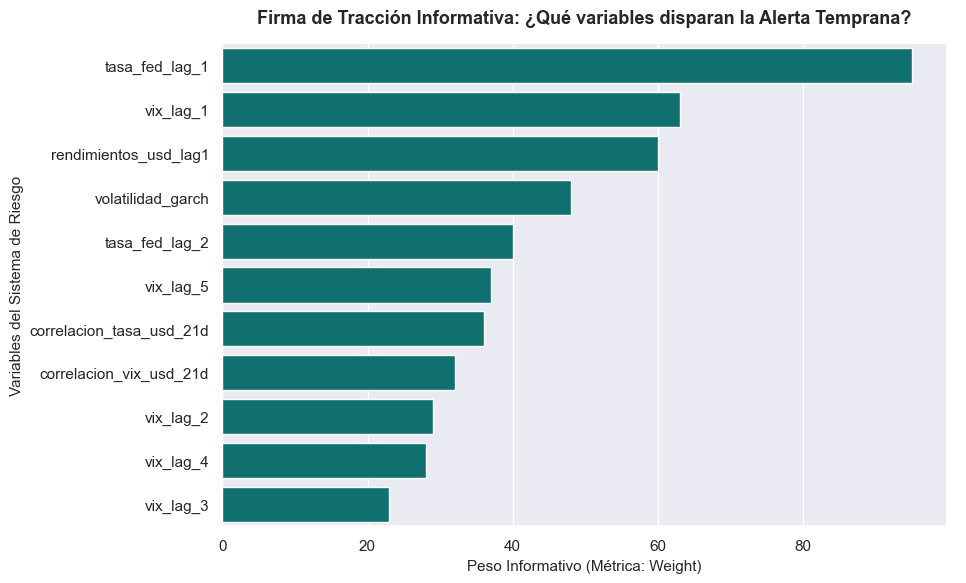

In [19]:
sns.set_theme(style="darkgrid")

# extracción de las relevancias de xgboost
importancias_dict = modelo_xgb.get_booster().get_score(importance_type='weight')

df_importancia = (
    pd.DataFrame({
        'Variable': list(importancias_dict.keys()),
        'Traccion_Informativa': list(importancias_dict.values())
    })
    .sort_values(by='Traccion_Informativa', ascending=False)
    .head(11)
)

g = sns.catplot(
    data=df_importancia,
    x='Traccion_Informativa',
    y='Variable',
    kind='bar',          
    color='teal',        
    height=6,           
    aspect=1.6          
)

g.ax.set_title(
    "Firma de Tracción Informativa: ¿Qué variables disparan la Alerta Temprana?", 
    fontsize=13, 
    fontweight='bold', 
    pad=15
)
g.set_axis_labels('Peso Informativo (Métrica: Weight)', 'Variables del Sistema de Riesgo', fontsize=11)

plt.tight_layout()
plt.show()


The XGBoost feature importance plot (measured by split weight) provides empirical validation of the multi-variable risk drivers that trigger the early warning system for the Mexican Peso:

* Dominance of Monetary Policy Shocks (tasa_fed_lag_1): In alignment with the initial Granger Causality analysis, the short-term interest rate differential acts as the primary structural driver for extreme currency movements. A sudden shift in the 10-year U.S. Treasury yield from the previous day carries the highest predictive weight, outperforming global equity market panic.


* The Immediate Risk Channel (vix_lag_1 vs. vix_lag_2): While the univariate econometric analysis identified the VIX as an AR(2) process, the machine learning classifier ranks vix_lag_2 significantly lower than vix_lag_1. This discrepancy does not contradict the statistical structure of market fear; instead, it reflects information redundancy within multivariate trees. Once XGBoost utilizes vix_lag_1 to partition the feature space, the incremental predictive power provided by vix_lag_2 diminishes due to multicollinearity.


* Risk and Interaction Context:The high ranking of rendimientos_usd_lag1 and volatilidad_garch confirms that internal currency momentum and conditional variance feedback loops are vital for detecting regime shifts. Furthermore, the inclusion of the 21-day rolling Spearman correlations provides the non-linear coupling context required for the tree-based model to map the transition into a panic state (Class 1).

## Project Conclusions: The Machine Learning Risk Layer

This final notebook successfully completes the structural risk management pipeline by transitioning from traditional parametric estimation into an ensemble Machine Learning framework. While the GARCH(1,1) architecture established in Notebook 2 provides an exceptional baseline for tracking continuous daily volatility, it lacks the flexibility to anticipate discrete structural regime shifts. Implementing the calibrated XGBoost classifier effectively bridges this gap, equipping the corporate treasury with a proactive Early Warning System (EWS).

By intentionally enforcing a 60% Recall floor to manage severe class imbalance, the model was optimized to prioritize systemic risk coverage over absolute accuracy. Operating under a dynamic decision threshold of 24.40%, the algorithm effectively captured 67% (4 out of 6) of actual out-of-sample financial panic events. Although this conservative cutoff introduces a trade-off by generating 137 False Positives, the operational costs of maintaining defensive hedges are vastly outweighed by the catastrophic capital erosion prevented during unmitigated currency devaluations.

Furthermore, the feature importance analysis confirmed that immediate U.S. monetary policy shocks ('tasa_fed_lag_1') and Wall Street stress indicators ('vix_lag_1') are the dominant catalysts for extreme capital flight in emerging markets. When combined with medium-term rolling Spearman correlations, the tree-based model successfully mapped the non-linear coupling of macro indicators prior to market stress. 

In conclusion, this integrated infrastructure—moving from Macro Lead Indicators to Econometric Volatility Modeling and culminating in Machine Learning Regime Classification—provides a production-grade framework for dynamic corporate hedging, cash flow protection, and institutional risk mitigation.